# Galaxy Merger Simulation
**Course:** AST 347 - Cosmology Final Project  
**Author:** Madalyn McDowall  
**Date:** Fall 2025

## Physical Context
Galaxy mergers are fundamental processes in galaxy evolution. This simulation demonstrates:
- Tidal stripping of satellite galaxies
- Dynamical friction causing orbital decay
- Formation of tidal streams
- Mass ratio effects (10:1 merger)

## Key Features
- **Main galaxy**: 500 disk particles + 100 bulge particles
- **Satellite galaxy**: 80 particles
- **Mass ratio**: 10:1 (main:satellite)
- **Dark matter halo**: NFW-like potential
- **Physical effects**: Dynamical friction, tidal forces

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec

# Physical constants
G = 1.0  # Gravitational constant

## Simulation Parameters

We use N-body units where G=1. The time scale is calibrated so that 1 code unit ≈ 1.5 Gyr, making the total simulation time ~45 Gyr. The mass ratio of 10:1 represents a minor merger scenario.

In [2]:
# Simulation parameters
steps = 2000
dt = 0.015
time_scale = 1.5  # Gyr per code unit
n_disk = 500
n_bulge = 100
n_sat = 80
n_total = n_disk + n_bulge + n_sat

soft = 0.15  # Softening length

# Main galaxy parameters
M_disk = 1.0
M_bulge = 0.3
M_halo = 8.0      # Dark matter halo mass
a_halo = 6.0      # Halo scale length
a_bulge = 0.8     # Bulge scale length

# Satellite galaxy parameters
M_sat = 0.13      # Mass ratio: (M_disk + M_bulge)/M_sat = 10:1
sat_scale = 0.5
sat_center = np.array([12.0, 2.0])      # Initial position
sat_bulkvel = np.array([-0.5, 0.55])    # Initial velocity

In [3]:
print(f"Simulation setup:")
print(f"  Main galaxy mass: {M_disk + M_bulge:.2f}")
print(f"  Satellite mass: {M_sat:.2f}")
print(f"  Mass ratio: {(M_disk + M_bulge)/M_sat:.1f}:1")
print(f"  Total particles: {n_total}")
print(f"  Simulation time: {steps * dt * time_scale:.1f} Gyr")

Simulation setup:
  Main galaxy mass: 1.30
  Satellite mass: 0.13
  Mass ratio: 10.0:1
  Total particles: 680
  Simulation time: 45.0 Gyr


## Particle Initialization

We initialize three particle populations:

1. **Disk**: Exponential surface density profile with rotation curve matching circular velocity
2. **Bulge**: Hernquist profile with velocity dispersion support
3. **Satellite**: Small galaxy with its own internal structure

All components are initialized with appropriate kinematic properties to ensure stability.

In [4]:
# Initialize particle arrays
pos = np.zeros((n_total, 2))
vel = np.zeros((n_total, 2))
mass = np.zeros(n_total)

# Define component ranges
idx_disk = slice(0, n_disk)
idx_bulge = slice(n_disk, n_disk + n_bulge)
idx_sat = slice(n_disk + n_bulge, n_total)

In [5]:
# Setup disk particles with exponential distribution
rs = np.random.exponential(scale=3.5, size=n_disk)
ths = np.random.uniform(0, 2*np.pi, n_disk)
pos[idx_disk, 0] = rs * np.cos(ths)
pos[idx_disk, 1] = rs * np.sin(ths)
pos[idx_disk] += np.random.normal(scale=0.1, size=(n_disk, 2))
mass[idx_disk] = M_disk / n_disk

# Calculate circular velocities for disk
def total_enclosed_mass(r):
    """
    Total mass enclosed within radius r (halo + disk + bulge).
    
    Used to compute rotation curve for disk initialization.
    """
    M_h = M_halo * r**2 / (r + a_halo)**2
    M_d = M_disk * (1 - np.exp(-r/3.5) * (1 + r/3.5))
    M_b = M_bulge * r**3 / (r + a_bulge)**3
    return M_h + M_d + M_b

r_disk = np.maximum(np.sqrt(np.sum(pos[idx_disk]**2, axis=1)), 1e-6)
v_circ = np.sqrt(G * total_enclosed_mass(r_disk) / r_disk)
vel[idx_disk, 0] = -v_circ * np.sin(ths)
vel[idx_disk, 1] = v_circ * np.cos(ths)
vel[idx_disk] += np.random.normal(scale=0.08, size=(n_disk, 2))

In [6]:
# Setup bulge particles (Hernquist profile)
u = np.random.uniform(0, 1, n_bulge)
r_bulge = a_bulge * np.sqrt(u) / (1 - np.sqrt(u))
th_bulge = np.random.uniform(0, 2*np.pi, n_bulge)
pos[idx_bulge, 0] = r_bulge * np.cos(th_bulge)
pos[idx_bulge, 1] = r_bulge * np.sin(th_bulge)
mass[idx_bulge] = M_bulge / n_bulge

v_bulge_disp = np.sqrt(G * M_bulge / (2 * a_bulge))
vel[idx_bulge] = np.random.normal(scale=v_bulge_disp, size=(n_bulge, 2))

# Setup satellite particles
u_sat = np.random.uniform(0, 1, n_sat)
r_sat_local = sat_scale * np.sqrt(u_sat) / (1 - np.sqrt(u_sat) + 0.1)
th_sat = np.random.uniform(0, 2*np.pi, n_sat)
pos[idx_sat, 0] = sat_center[0] + r_sat_local * np.cos(th_sat)
pos[idx_sat, 1] = sat_center[1] + r_sat_local * np.sin(th_sat)
mass[idx_sat] = M_sat / n_sat

v_sat_disp = np.sqrt(G * M_sat / (2 * sat_scale))
vel[idx_sat, 0] = sat_bulkvel[0] + np.random.normal(scale=v_sat_disp, size=n_sat)
vel[idx_sat, 1] = sat_bulkvel[1] + np.random.normal(scale=v_sat_disp, size=n_sat)

In [7]:
# Arrays to store simulation history
history = np.zeros((steps, n_total, 2))
sat_center_history = np.zeros((steps, 2))

# Masks to identify particle types
is_disk = np.zeros(n_total, dtype=bool)
is_disk[idx_disk] = True
is_bulge = np.zeros(n_total, dtype=bool)
is_bulge[idx_bulge] = True
is_sat = np.zeros(n_total, dtype=bool)
is_sat[idx_sat] = True

## Physics Implementations

### Dark Matter Halo
NFW-like potential providing the dominant gravitational potential at large radii.

### Dynamical Friction
Chandrasekhar's formula for orbital decay due to gravitational wake in the dark matter halo.

### Tidal Radius
Roche limit beyond which satellite particles become unbound and form tidal streams.

In [8]:
def halo_acceleration(positions):
    """
    Acceleration from dark matter halo (NFW-like profile).
    
    Parameters:
    positions : ndarray (N, 2)
        Particle positions
        
    Returns:
    acc : ndarray (N, 2)
        Accelerations from halo
    """
    r = np.linalg.norm(positions, axis=1, keepdims=True)
    r = np.maximum(r, 1e-6)
    factor = -G * M_halo / (r + a_halo)**2
    return factor * (positions / r)

def bulge_acceleration(positions):
    """Acceleration from central bulge (Hernquist profile)."""
    r = np.linalg.norm(positions, axis=1, keepdims=True)
    r = np.maximum(r, 1e-6)
    factor = -G * M_bulge / (r + a_bulge)**2
    return factor * (positions / r)

def particle_acceleration(pos, mass):
    """
    Calculate particle-particle gravitational interactions.
    
    Uses softening to prevent numerical divergences.
    """
    dx = pos[:, None, :] - pos[None, :, :]
    r2 = np.sum(dx**2, axis=2) + soft**2
    inv_r3 = 1.0 / (r2 * np.sqrt(r2))
    np.fill_diagonal(inv_r3, 0.0)
    factor = (mass[None, :] * inv_r3)[:, :, None]
    return -G * np.sum(dx * factor, axis=1)

In [9]:
def tidal_radius(M_sat, r_center, M_enc):
    """
    Calculate tidal radius (Roche limit) for satellite.
    
    Particles beyond ~2 × tidal radius are considered unbound.
    """
    if M_enc <= 0:
        return np.inf
    return r_center * (M_sat / (3 * M_enc))**(1/3)

def dynamical_friction(v_sat, M_sat, rho):
    """
    Chandrasekhar dynamical friction formula.
    
    Causes satellite to spiral inward due to gravitational wake.
    """
    v_mag = np.linalg.norm(v_sat)
    if v_mag < 1e-6:
        return np.zeros(2)
    coeff = 4 * np.pi * G**2 * M_sat * rho * 3.0
    return -0.4 * coeff * v_sat / (v_mag**3 + 1e-9)

## Time Integration

Using leapfrog (kick-drift-kick) integration for symplectic time evolution. Dynamical friction is applied only to satellite particles to model their orbital decay.

In [10]:
print(f"Running merger simulation:")
print(f"  Main galaxy: {n_disk} disk + {n_bulge} bulge particles")
print(f"  Satellite: {n_sat} particles")
print(f"  Mass ratio: {(M_disk+M_bulge)/M_sat:.1f}:1")
print(f"  Time steps: {steps}\n")

Running merger simulation:
  Main galaxy: 500 disk + 100 bulge particles
  Satellite: 80 particles
  Mass ratio: 10.0:1
  Time steps: 2000



In [11]:
# Initial acceleration (half-step for leapfrog)
acc = particle_acceleration(pos, mass)
acc += halo_acceleration(pos)
acc += bulge_acceleration(pos)
vel += 0.5 * acc * dt

# Main time integration loop
for step in range(steps):
    # Update positions
    pos += vel * dt
    
    # Calculate all accelerations
    acc = particle_acceleration(pos, mass)
    acc += halo_acceleration(pos)
    acc += bulge_acceleration(pos)
    
    # Calculate satellite center of mass
    sat_pos_center = pos[is_sat].mean(axis=0)
    sat_vel_center = vel[is_sat].mean(axis=0)
    r_sat = np.linalg.norm(sat_pos_center)
    
    # Add dynamical friction to satellite
    rho_halo = (M_halo * a_halo) / (2 * np.pi * max(r_sat, 1e-3) * \
                                     (r_sat + a_halo)**3)
    a_df = dynamical_friction(sat_vel_center, M_sat, rho_halo)
    acc[is_sat] += a_df
    
    # Update velocities
    vel += acc * dt
    
    # Store data for animation
    history[step] = pos.copy()
    sat_center_history[step] = sat_pos_center
    
    # Print progress
    if step % 200 == 0:
        sat_distances = np.linalg.norm(pos[is_sat] - sat_pos_center, axis=1)
        M_enc = total_enclosed_mass(r_sat)
        r_tid = tidal_radius(M_sat, r_sat, M_enc)
        bound_count = np.sum(sat_distances < 2 * r_tid)
        bound_percent = 100.0 * bound_count / n_sat
        print(f"  t={step*dt*time_scale:.2f} Gyr | Bound: {bound_percent:.1f}% | " + \
              f"r_sat={r_sat:.2f}")

  t=0.00 Gyr | Bound: 100.0% | r_sat=11.97
  t=4.50 Gyr | Bound: 97.5% | r_sat=10.77
  t=9.00 Gyr | Bound: 76.2% | r_sat=9.63
  t=13.50 Gyr | Bound: 60.0% | r_sat=8.65
  t=18.00 Gyr | Bound: 47.5% | r_sat=8.01
  t=22.50 Gyr | Bound: 42.5% | r_sat=7.88
  t=27.00 Gyr | Bound: 35.0% | r_sat=8.22
  t=31.50 Gyr | Bound: 31.2% | r_sat=8.87
  t=36.00 Gyr | Bound: 27.5% | r_sat=9.71
  t=40.50 Gyr | Bound: 26.2% | r_sat=10.62


## Visualization

Creating dual-panel animation:
- **Left panel**: Full view showing tidal streams
- **Right panel**: Zoomed view of central merger region

Color coding key:
- Blue: Main disk
- Gold: Main bulge
- Red: Bound satellite particles
- Orange: Unbound particles (tidal stream)

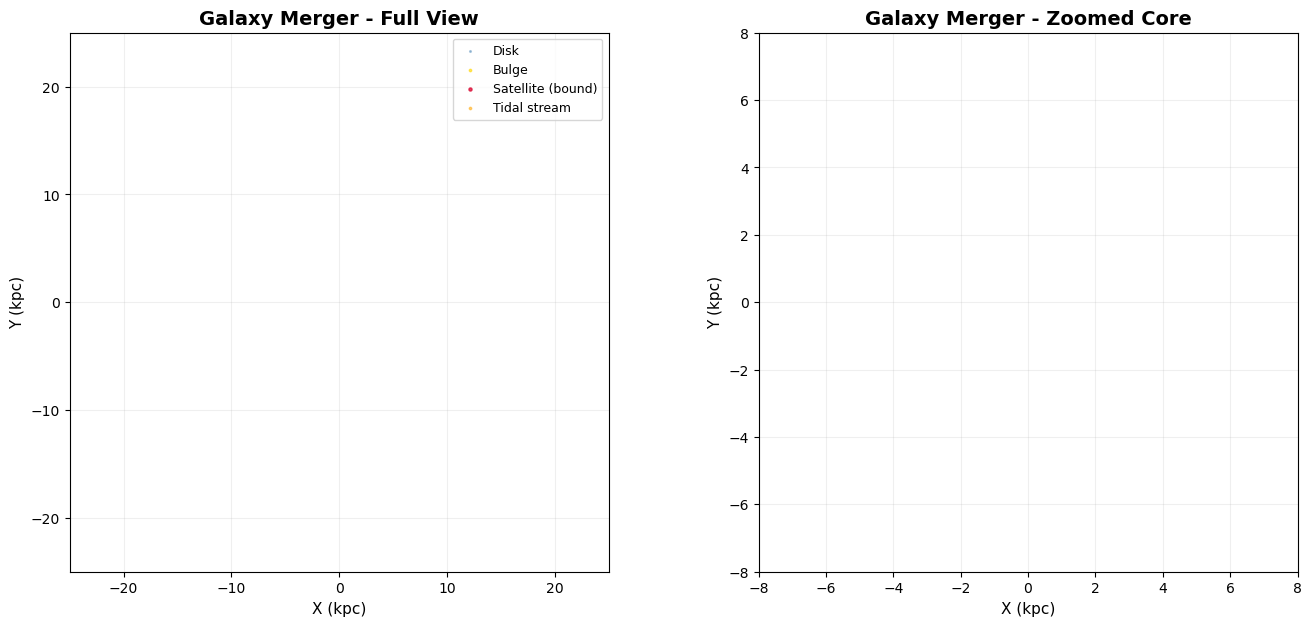

In [12]:
# Setup figure with two viewing panels
fig = plt.figure(figsize=(16, 7))
gs = GridSpec(1, 2, figure=fig, wspace=0.25)

ax_full = fig.add_subplot(gs[0, 0])
ax_zoom = fig.add_subplot(gs[0, 1])

# Configure axes
ax_full.set_xlim([-25, 25])
ax_full.set_ylim([-25, 25])
ax_full.set_aspect('equal')
ax_full.set_title("Galaxy Merger - Full View", fontsize=14, fontweight='bold')
ax_full.set_xlabel('X (kpc)', fontsize=11)
ax_full.set_ylabel('Y (kpc)', fontsize=11)
ax_full.grid(alpha=0.2)

ax_zoom.set_xlim([-8, 8])
ax_zoom.set_ylim([-8, 8])
ax_zoom.set_aspect('equal')
ax_zoom.set_title("Galaxy Merger - Zoomed Core", fontsize=14, fontweight='bold')
ax_zoom.set_xlabel('X (kpc)', fontsize=11)
ax_zoom.set_ylabel('Y (kpc)', fontsize=11)
ax_zoom.grid(alpha=0.2)

# Create scatter plots for full view
disk_full = ax_full.scatter([], [], s=1.5, c='steelblue', alpha=0.4, label='Disk')
bulge_full = ax_full.scatter([], [], s=3, c='gold', alpha=0.6, label='Bulge')
sat_bound_full = ax_full.scatter([], [], s=5, c='crimson', alpha=0.8, 
                                 label='Satellite (bound)')
sat_unbound_full = ax_full.scatter([], [], s=3, c='orange', alpha=0.5, 
                                   label='Tidal stream')

# Create scatter plots for zoom view
disk_zoom = ax_zoom.scatter([], [], s=2, c='steelblue', alpha=0.4)
bulge_zoom = ax_zoom.scatter([], [], s=4, c='gold', alpha=0.6)
sat_bound_zoom = ax_zoom.scatter([], [], s=6, c='crimson', alpha=0.8)
sat_unbound_zoom = ax_zoom.scatter([], [], s=4, c='orange', alpha=0.5)

ax_full.legend(loc='upper right', fontsize=9)

# Add trajectory line
traj_line, = ax_full.plot([], [], 'r--', alpha=0.4, lw=1, 
                          label='Satellite orbit')

# Add time text box
time_text = ax_full.text(0.02, 0.97, '', transform=ax_full.transAxes,
                         fontsize=12, verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

In [13]:
def update(frame):
    """Update function for animation."""
    p = history[frame]
    
    disk = p[is_disk]
    bulge = p[is_bulge]
    sat = p[is_sat]
    
    # Determine which satellite particles are still bound
    sat_center = sat_center_history[frame]
    sat_rel = sat - sat_center
    sat_r = np.linalg.norm(sat_rel, axis=1)
    r_sat_pos = np.linalg.norm(sat_center)
    M_enc = total_enclosed_mass(r_sat_pos)
    r_tid = tidal_radius(M_sat, r_sat_pos, M_enc)
    
    bound_mask = sat_r < 2 * r_tid
    sat_bound = sat[bound_mask]
    sat_unbound = sat[~bound_mask]
    
    # Update full view
    disk_full.set_offsets(disk)
    bulge_full.set_offsets(bulge)
    sat_bound_full.set_offsets(sat_bound)
    sat_unbound_full.set_offsets(sat_unbound)
    
    # Update zoom view
    disk_zoom.set_offsets(disk)
    bulge_zoom.set_offsets(bulge)
    sat_bound_zoom.set_offsets(sat_bound)
    sat_unbound_zoom.set_offsets(sat_unbound)
    
    # Update trajectory
    traj_line.set_data(sat_center_history[:frame+1, 0], 
                       sat_center_history[:frame+1, 1])
    
    # Update time display
    bound_frac = len(sat_bound) / len(sat) * 100
    time_text.set_text(f't = {frame * dt * time_scale:.2f} Gyr\n' + \
                       f'Bound: {bound_frac:.1f}%')
    
    return (disk_full, bulge_full, sat_bound_full, sat_unbound_full,
            disk_zoom, bulge_zoom, sat_bound_zoom, sat_unbound_zoom,
            traj_line, time_text)

In [ ]:
# Create animation
ani = FuncAnimation(fig, update, frames=steps, interval=100, blit=False)
ani.save("galaxy_merger.gif", writer="pillow", fps=30)
plt.show()


Saving animation...
✓ Saved as galaxy_merger.gif
